# Adversarial Robustness on CIFAR-10 using CNN and PGD Adversarial Training

## Objective
The goal of this project is to study the vulnerability of deep neural networks to adversarial attacks and improve robustness using adversarial training. A convolutional neural network (CNN) is first trained on the CIFAR-10 dataset under normal conditions. Then, a Projected Gradient Descent (PGD) attack is used to generate adversarial examples and evaluate how badly the model fails. Finally, adversarial training is applied to improve robustness, and the results are compared.

## Dataset
CIFAR-10

## Methods
- Standard CNN
- PGD Attack
- Adversarial Training

## Evaluation
- Clean Accuracy
- Adversarial Accuracy

In [2]:
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [4]:
os.makedirs("saved_models", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("report_figures", exist_ok=True)

print("Folders created successfully.")

Folders created successfully.


In [5]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
])

trainset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform_train
)

testset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform_test
)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print("Training samples:", len(trainset))
print("Test samples:", len(testset))

Training samples: 50000
Test samples: 10000


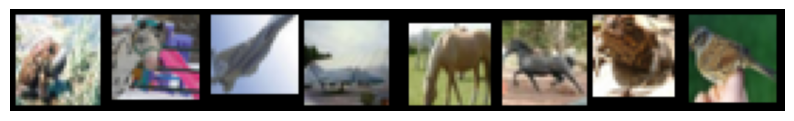

Labels: ['frog', 'horse', 'plane', 'plane', 'horse', 'horse', 'frog', 'bird']


In [6]:
def imshow(img):
    npimg = img.numpy()
    plt.figure(figsize=(10, 4))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

dataiter = iter(trainloader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:8]))
print("Labels:", [classes[label] for label in labels[:8]])

In [7]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.3)
        
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))   # 32x32 -> 16x16
        x = self.pool(F.relu(self.bn2(self.conv2(x))))   # 16x16 -> 8x8
        x = self.pool(F.relu(self.bn3(self.conv3(x))))   # 8x8 -> 4x4
        
        x = x.view(x.size(0), -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

In [8]:
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=2048, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)


In [9]:
def train_model(model, trainloader, criterion, optimizer, device, epochs=10):
    train_losses = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        start_time = time.time()
        
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        epoch_loss = running_loss / len(trainloader)
        train_losses.append(epoch_loss)
        end_time = time.time()
        
        print(f"Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f} Time: {end_time - start_time:.2f}s")
    
    return train_losses

In [10]:
def evaluate_model(model, dataloader, device):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = 100 * correct / total
    return accuracy

In [11]:
clean_model = SimpleCNN().to(device)
clean_optimizer = optim.Adam(clean_model.parameters(), lr=0.001)

clean_train_losses = train_model(
    clean_model, trainloader, criterion, clean_optimizer, device, epochs=10
)

Epoch [1/10] Loss: 1.4810 Time: 40.47s
Epoch [2/10] Loss: 1.1442 Time: 39.04s
Epoch [3/10] Loss: 1.0177 Time: 39.17s
Epoch [4/10] Loss: 0.9379 Time: 39.14s
Epoch [5/10] Loss: 0.8828 Time: 40.76s
Epoch [6/10] Loss: 0.8383 Time: 39.75s
Epoch [7/10] Loss: 0.8089 Time: 38.94s
Epoch [8/10] Loss: 0.7774 Time: 39.00s
Epoch [9/10] Loss: 0.7462 Time: 39.16s
Epoch [10/10] Loss: 0.7271 Time: 39.89s


In [12]:
clean_accuracy = evaluate_model(clean_model, testloader, device)
print(f"Clean Test Accuracy of Standard Model: {clean_accuracy:.2f}%")

Clean Test Accuracy of Standard Model: 76.25%


In [13]:
torch.save(clean_model.state_dict(), "saved_models/clean_model.pth")
print("Clean model saved.")

Clean model saved.


In [17]:
def pgd_attack(model, images, labels, eps=4/255, alpha=1/255, iters=5):
    images = images.clone().detach().to(device)
    labels = labels.to(device)

    original_images = images.clone().detach()
    adv_images = images.clone().detach()

    for _ in range(iters):
        adv_images.requires_grad = True

        outputs = model(adv_images)
        loss = criterion(outputs, labels)

        model.zero_grad()
        loss.backward()

        adv_images = adv_images + alpha * adv_images.grad.sign()

        eta = torch.clamp(adv_images - original_images, min=-eps, max=eps)
        adv_images = torch.clamp(original_images + eta, min=0, max=1).detach()

    return adv_images

In [18]:
def evaluate_under_attack(model, dataloader, device, eps=8/255, alpha=2/255, iters=10):
    model.eval()
    correct = 0
    total = 0
    
    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        adv_images = pgd_attack(model, images, labels, eps=eps, alpha=alpha, iters=iters)
        
        outputs = model(adv_images)
        _, predicted = torch.max(outputs, 1)
        
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    adv_accuracy = 100 * correct / total
    return adv_accuracy

In [19]:
clean_model_adv_accuracy = evaluate_under_attack(
    clean_model, testloader, device,
    eps=4/255,
    alpha=1/255,
    iters=5
)
print(f"Adversarial Accuracy of Standard Model: {clean_model_adv_accuracy:.2f}%")

Adversarial Accuracy of Standard Model: 2.29%


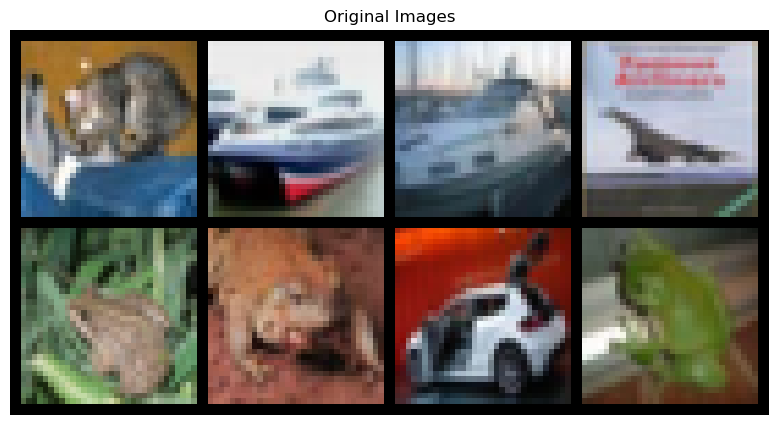

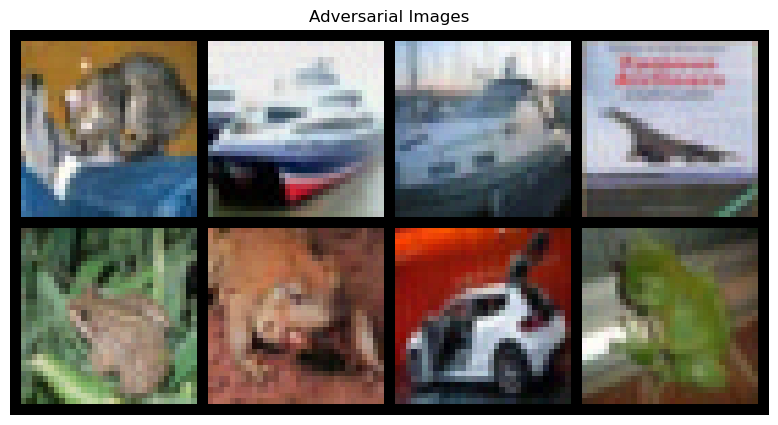

In [20]:
dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images[:8].to(device), labels[:8].to(device)

adv_images = pgd_attack(clean_model, images, labels)

def show_tensor_images(imgs, title):
    imgs = imgs.cpu().detach()
    grid = torchvision.utils.make_grid(imgs, nrow=4)
    npimg = grid.numpy()
    plt.figure(figsize=(10, 5))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(title)
    plt.axis('off')
    plt.show()

show_tensor_images(images, "Original Images")
show_tensor_images(adv_images, "Adversarial Images")

In [21]:
def adversarial_train_model(model, trainloader, criterion, optimizer, device, epochs=10,
                            eps=8/255, alpha=2/255, iters=7):
    train_losses = []
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        start_time = time.time()
        
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            
            adv_images = pgd_attack(model, images, labels, eps=eps, alpha=alpha, iters=iters)
            
            optimizer.zero_grad()
            outputs = model(adv_images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        epoch_loss = running_loss / len(trainloader)
        train_losses.append(epoch_loss)
        end_time = time.time()
        
        print(f"Adversarial Epoch [{epoch+1}/{epochs}] Loss: {epoch_loss:.4f} Time: {end_time - start_time:.2f}s")
    
    return train_losses

In [22]:
robust_model = SimpleCNN().to(device)
robust_optimizer = optim.Adam(robust_model.parameters(), lr=0.001)

robust_train_losses = adversarial_train_model(
    robust_model, trainloader, criterion, robust_optimizer, device, epochs=10
)

Adversarial Epoch [1/10] Loss: 2.1272 Time: 238.38s
Adversarial Epoch [2/10] Loss: 2.0315 Time: 233.55s
Adversarial Epoch [3/10] Loss: 1.9997 Time: 234.71s
Adversarial Epoch [4/10] Loss: 1.9773 Time: 401.74s
Adversarial Epoch [5/10] Loss: 1.9607 Time: 249.54s
Adversarial Epoch [6/10] Loss: 1.9458 Time: 236.89s
Adversarial Epoch [7/10] Loss: 1.9311 Time: 238.51s
Adversarial Epoch [8/10] Loss: 1.9249 Time: 357.33s
Adversarial Epoch [9/10] Loss: 1.9149 Time: 239.96s
Adversarial Epoch [10/10] Loss: 1.9056 Time: 543.98s


In [23]:
robust_clean_accuracy = evaluate_model(robust_model, testloader, device)
print(f"Clean Test Accuracy of Robust Model: {robust_clean_accuracy:.2f}%")

Clean Test Accuracy of Robust Model: 49.46%


In [24]:
robust_adv_accuracy = evaluate_under_attack(robust_model, testloader, device)
print(f"Adversarial Accuracy of Robust Model: {robust_adv_accuracy:.2f}%")

Adversarial Accuracy of Robust Model: 31.48%


In [25]:
torch.save(robust_model.state_dict(), "saved_models/robust_model.pth")
print("Robust model saved.")

Robust model saved.


In [26]:
results = {
    "Standard Model Clean Accuracy": clean_accuracy,
    "Standard Model Adversarial Accuracy": clean_model_adv_accuracy,
    "Robust Model Clean Accuracy": robust_clean_accuracy,
    "Robust Model Adversarial Accuracy": robust_adv_accuracy
}

for key, value in results.items():
    print(f"{key}: {value:.2f}%")

Standard Model Clean Accuracy: 76.25%
Standard Model Adversarial Accuracy: 2.29%
Robust Model Clean Accuracy: 49.46%
Robust Model Adversarial Accuracy: 31.48%


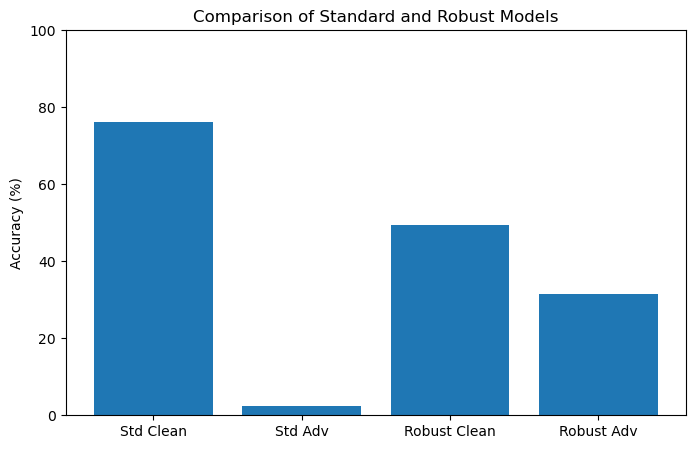

In [27]:
labels = [
    "Std Clean",
    "Std Adv",
    "Robust Clean",
    "Robust Adv"
]

values = [
    clean_accuracy,
    clean_model_adv_accuracy,
    robust_clean_accuracy,
    robust_adv_accuracy
]

plt.figure(figsize=(8, 5))
plt.bar(labels, values)
plt.ylabel("Accuracy (%)")
plt.title("Comparison of Standard and Robust Models")
plt.ylim(0, 100)
plt.savefig("report_figures/accuracy_comparison.png")
plt.show()

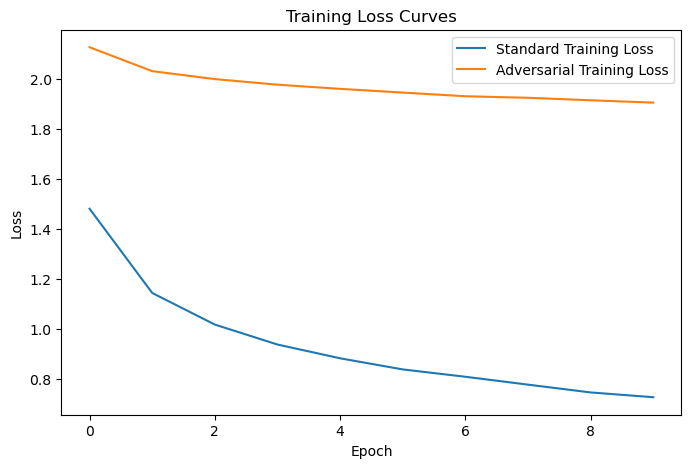

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(clean_train_losses, label="Standard Training Loss")
plt.plot(robust_train_losses, label="Adversarial Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curves")
plt.legend()
plt.savefig("report_figures/training_loss_curves.png")
plt.show()

## Conclusion

This project demonstrated the vulnerability of convolutional neural networks to adversarial attacks on CIFAR-10. The standard CNN achieved good performance on clean test images, but its accuracy dropped sharply when evaluated on PGD-generated adversarial examples. This confirms that high clean accuracy alone does not imply robustness.

To address this weakness, adversarial training was applied. Although the robust model showed a small reduction in clean accuracy, it achieved a clear improvement in adversarial accuracy. These results demonstrate the trade-off between standard accuracy and robustness, while also showing that adversarial training is an effective defense mechanism.